# Phase 2 — Data Cleaning
**Goal:** clean the raw records from `data/raw/` into consistent, conversation-ready text records in
`data/processed/cleaned/` — with **no** prompt/response formatting (that is Phase 3).

The reusable logic lives in `src/data/cleaning.py`; all parameters come from
`configs/data_config.yaml`.

**Cleaning steps performed**
1. **Encoding/whitespace** — NFKC normalization, smart-quote/dash/ellipsis → ASCII, control-char stripping, whitespace collapse.
2. **Noise removal** — HTML tags and URLs.
3. **PII redaction** — emails, phone numbers, SSNs, card numbers, IPs → `[EMAIL]`, `[PHONE]`, ...
4. **Quality filters** — length bounds, alphabetic ratio, financial-content check.
5. **Numeric financial-profiling exclusion** — records framed as salary / income / expense / net-worth /
   risk-score *prediction* are dropped (this product is a Q&A chatbot, not a profiler).
6. **Deduplication** — exact + same-question + fuzzy (difflib) collapse.

*Inputs:* `data/raw/<source>/sample.jsonl` · *Outputs:* `data/processed/cleaned/<source>.jsonl`


In [1]:
"""Setup: paths, config, imports."""
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import yaml

# root = first ancestor that looks like this project (works from any launch dir)
_here = Path.cwd().resolve()
PROJECT_ROOT = next(
    (c for c in [_here, *_here.parents]
     if (c / "docs").is_dir() and (c / "data").is_dir() and (c / "notebooks").is_dir()),
    _here,
)
sys.path.insert(0, str(PROJECT_ROOT))

from src.data import cleaning as cl  # noqa: E402

RAW_DIR = PROJECT_ROOT / "data" / "raw"
OUT_DIR = PROJECT_ROOT / "data" / "processed" / "cleaned"
CONFIG_PATH = PROJECT_ROOT / "configs" / "data_config.yaml"

with open(CONFIG_PATH, "r", encoding="utf-8") as fh:
    cfg_raw = yaml.safe_load(fh)["cleaning"]

# Merge the YAML over the built-in defaults (YAML keys override defaults).
cfg = cl.merge_config(cfg_raw)

print("Project root:", PROJECT_ROOT)
print("Config loaded from:", CONFIG_PATH)
print("Effective key parameters:")
for group in ("dedup", "filtering", "profiling_exclusion"):
    print(f"  {group}: {cfg.get(group)}")

Project root: C:\Users\AbdElhalk\OneDrive\Desktop\NLP Projects\Financial Advice Chatbot
Config loaded from: C:\Users\AbdElhalk\OneDrive\Desktop\NLP Projects\Financial Advice Chatbot\configs\data_config.yaml
Effective key parameters:
  dedup: {'enabled': True, 'threshold': 0.92, 'use_fuzzy': True, 'block_prefix': 8}
  filtering: {'min_question_chars': 15, 'max_question_chars': 5000, 'min_answer_words': 3, 'max_answer_chars': 12000, 'min_alpha_ratio': 0.55, 'min_financial_hits': 1}
  profiling_exclusion: {'enabled': True}


## 1. Guardrail sanity checks

Before running the pipeline, verify the *exclusion* logic behaves as intended:
- detecting true numeric-profiling questions (drop them),
- keeping advice questions and company-financials questions that merely *mention* a number, and
- dedup / PII / encoding primitives behave correctly.


In [2]:
"""Soft-check the core cleaning primitives."""
cases = [
    # (kind, call, description)
    ("profiling", cl.is_profiling_record("What is my net worth?"), "What is my net worth?"),
    ("profiling", cl.is_profiling_record("Predict my annual salary from my age and education"),
     "Predict my annual salary from my age and education"),
    ("profiling", cl.is_profiling_record("Estimate your monthly expenses for the next year"),
     "Estimate your monthly expenses for the next year"),
    ("profiling", cl.is_profiling_record("How much am I worth?"), "How much am I worth?"),
    ("profiling", cl.is_profiling_record("Calculate my risk score"), "Calculate my risk score"),
    ("NOT-profiling", not cl.is_profiling_record("Should I pay off debt or invest my savings?"),
     "advice: pay off debt or invest?"),
    ("NOT-profiling", not cl.is_profiling_record("I make 150k a year and saved 100k, should I buy a house?"),
     "advice mentioning income as context"),
    ("NOT-profiling", not cl.is_profiling_record("What is the FY2018 capital expenditure for 3M?"),
     "company-level financial question"),
    ("NOT-profiling", not cl.is_profiling_record("I calculated that my necessary expenses run about 800/mo, is that normal?"),
     "narrative 'calculated' as context"),
    ("financial", cl.is_financial_record("Should I invest in ETFs?", ""), "'ETFs' keeps a record"),
    ("NOT-financial", not cl.is_financial_record("What is the best pizza topping?", ""), "'pizza' drops a record"),
]

def dedup_ok():
    recs = [
        {"question": "How do I start an emergency fund?", "answer": "Save 3-6 months of expenses."},
        {"question": "How do I start an emergency fund?", "answer": "Save 3-6 months of expenses."},
        {"question": "How do I start an emergency fund?", "answer": "Put aside three to six months of spending."},
        {"question": "How do I start an emergency fund?", "answer": "another phrasing of the same question"},
        {"question": "What are ETFs?", "answer": "Exchange-traded funds track an index."},
    ]
    kept, n_e, n_s, n_f = cl.deduplicate(recs, threshold=0.9)
    return n_e == 1 and n_s == 2 and n_f == 0 and len(kept) == 2

def pii_ok():
    out, n = cl.redact_pii("mail bob@example.com call 555-123-4567 SSN 123-45-6789", count=True)
    return n == 3 and "[EMAIL]" in out and "[PHONE]" in out and "[SSN]" in out

def enc_ok():
    norm = cl.normalize_text("I\u2019m fine \u2014 really\u2026not.", cl.DEFAULT_CONFIG)
    return "I'm fine - really...not." in norm

extra = [
    ("dedup", dedup_ok(), "exact + same-question + fuzzy collapse"),
    ("PII", pii_ok(), "email/phone/SSN redacted to placeholders"),
    ("encoding", enc_ok(), "smart quotes/dashes -> ASCII"),
    ("profiling", all(ok for kind, ok, *_ in cases if kind == "profiling"), "all profiling cases"),
    ("NOT-profiling", all(ok for kind, ok, *_ in cases if kind == "NOT-profiling"), "all keep-cases"),
    ("financial", all(ok for kind, ok, *_ in cases if kind == "financial"), "financial-content checks"),
]

rows = [(kind, desc, "PASS" if ok else "FAIL") for kind, ok, *desc in [*cases[:11], *extra]]
summary = pd.DataFrame(rows, columns=["category", "check", "result"])
print(summary.to_string(index=False))
assert summary["result"].eq("PASS").all(), "guardrail check failed"

     category                                                check result
    profiling                              [What is my net worth?]   PASS
    profiling [Predict my annual salary from my age and education]   PASS
    profiling   [Estimate your monthly expenses for the next year]   PASS
    profiling                               [How much am I worth?]   PASS
    profiling                            [Calculate my risk score]   PASS
NOT-profiling                    [advice: pay off debt or invest?]   PASS
NOT-profiling                [advice mentioning income as context]   PASS
NOT-profiling                   [company-level financial question]   PASS
NOT-profiling                  [narrative 'calculated' as context]   PASS
    financial                              ['ETFs' keeps a record]   PASS
NOT-financial                             ['pizza' drops a record]   PASS
        dedup             [exact + same-question + fuzzy collapse]   PASS
          PII           [email/phone/S

## 2. Run the cleaning pipeline

Cleans every source listed (all sources present in `data/raw/`), writing one unified
`{source}.jsonl` per source. `before` is the raw row count, `after` the cleaned count.


In [3]:
"""Execute the pipeline across all raw sources."""
sources = sorted([p.name for p in RAW_DIR.iterdir() if (p / "sample.jsonl").is_file()])
print("Sources found in data/raw/:", sources)

stats = cl.clean_corpus(RAW_DIR, OUT_DIR, sources, cfg=cfg)

rows = []
for s in stats:
    rows.append({
        "source": s.source,
        "rows_before": s.n_before,
        "rows_after": s.n_after,
        "removed": s.n_before - s.n_after,
        "encoding_normalized": s.encoding_normalized,
        "pii_redacted": s.pii_redactions,
        "exact_dups": s.exact_duplicates,
        "same_q_dups": s.same_question_duplicates,
        "fuzzy_dups": s.fuzzy_duplicates,
        "profiling_removed": s.profiling_removed,
    })
summary_df = pd.DataFrame(rows)
print("Summary (before -> after):")
print(summary_df.to_string(index=False))
display(summary_df)

# drop-reason breakdown per source
reason_rows = []
for s in stats:
    for r, n in s.reasons.items():
        reason_rows.append({"source": s.source, "reason": r, "count": n})
reasons_df = pd.DataFrame(reason_rows)
if not reasons_df.empty:
    print("\nDrop reasons:")
    print(reasons_df.to_string(index=False))
    display(reasons_df)
else:
    print("\nNo records dropped by quality filters (all removals were dedup or none).")

Sources found in data/raw/: ['financebench', 'fingpt-fiqa-qa', 'personal-finance-v2']


Summary (before -> after):
             source  rows_before  rows_after  removed  encoding_normalized  pii_redacted  exact_dups  same_q_dups  fuzzy_dups  profiling_removed
       financebench          150         144        6                    0             0           0            0           6                  0
     fingpt-fiqa-qa          300         160      140                    5             0           0          139           0                  0
personal-finance-v2          300         298        2                   17            22           0            0           0                  0


,source,rows_before,rows_after,removed,encoding_normalized,pii_redacted,exact_dups,same_q_dups,fuzzy_dups,profiling_removed
0,financebench,150,144,6,0,0,0,0,6,0
1,fingpt-fiqa-qa,300,160,140,5,0,0,139,0,0
2,personal-finance-v2,300,298,2,17,22,0,0,0,0



Drop reasons:
             source            reason  count
     fingpt-fiqa-qa  answer_too_short      1
personal-finance-v2 question_too_long      2


,source,reason,count
0,fingpt-fiqa-qa,answer_too_short,1
1,personal-finance-v2,question_too_long,2


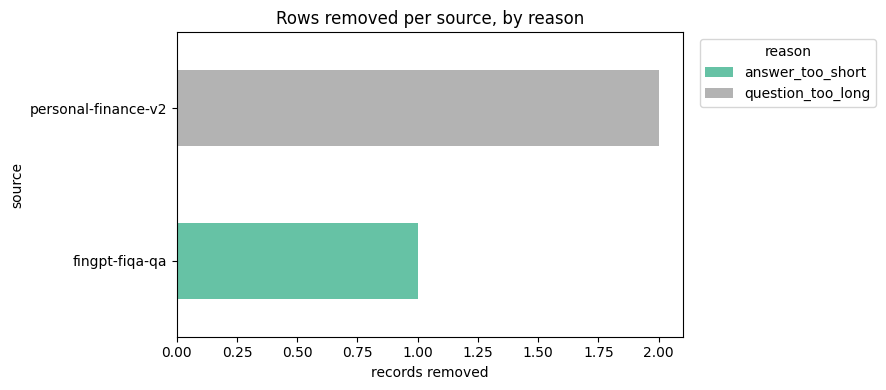

In [4]:
"""Drop-reason chart."""
pivot = reasons_df.pivot(index="source", columns="reason", values="count").fillna(0)
ax = pivot.plot.barh(stacked=True, figsize=(9, 4), colormap="Set2")
ax.set_title("Rows removed per source, by reason")
ax.set_xlabel("records removed")
ax.legend(bbox_to_anchor=(1.02, 1), title="reason")
plt.tight_layout()
plt.show()

## 3. PII and encoding-normalization effects

In [5]:
"""Show concrete redaction + normalization examples."""
example_q = "Contact my agent at bob@example.com or 555-123-4567 about the claim; my SSN is 123-45-6789."
print("Before:", example_q)
print("After :", cl.redact_pii(example_q))

curly = "I\u2019m planning an IRA \u2014 it\u2019s the right move\u2026"
print("\nBefore:", curly)
print("After :", cl.normalize_text(curly, cfg))

print("\nTotals across corpus:")
tot = summary_df[["encoding_normalized", "pii_redacted", "same_q_dups", "fuzzy_dups"]].sum()
print(tot.to_string())

Before: Contact my agent at bob@example.com or 555-123-4567 about the claim; my SSN is 123-45-6789.
After : Contact my agent at [EMAIL] or [PHONE] about the claim; my SSN is [SSN].

Before: I’m planning an IRA — it’s the right move…
After : I'm planning an IRA - it's the right move...

Totals across corpus:
encoding_normalized     22
pii_redacted            22
same_q_dups            139
fuzzy_dups               6


## 4. Sample cleaned records

Fragments previewed from the cleaned outputs (`data/processed/cleaned/`).


In [6]:
"""Preview cleaned records."""
def truncate(text: str, width: int = 200) -> str:
    text = str(text).replace("\n", " ")
    return text if len(text) <= width else text[: width - 3] + "..."

def show(rec) -> None:
    aux_keys = sorted(rec.get("aux", {}).keys())
    print(f"[{rec['source']}] {rec['id']}")
    print("  Q:", truncate(rec["question"]))
    print("  A:", truncate(rec["answer"]))
    if aux_keys:
        print("  aux fields:", ", ".join(aux_keys))
    print()

for source in sources:
    path = OUT_DIR / f"{source}.jsonl"
    recs = [json.loads(l) for l in path.read_text(encoding="utf-8").splitlines()]
    print("=" * 20, source, f"({len(recs)} cleaned records)")
    for rec in recs[:3]:
        show(rec)

==================== financebench (144 cleaned records)
[financebench] financebench-0000
  Q: What is the FY2018 capital expenditure amount (in USD millions) for 3M? Give a response to the question by relying on the details shown in the cash flow statement.
  A: $1577.00
  aux fields: company, dataset_subset_label, doc_link, doc_name, doc_period, doc_type, domain_question_num, evidence, financebench_id, gics_sector, justification, question_reasoning, question_type

[financebench] financebench-0001
  Q: Assume that you are a public equities analyst. Answer the following question by primarily using information that is shown in the balance sheet: what is the year end FY2018 net PPNE for 3M? Answer i...
  A: $8.70
  aux fields: company, dataset_subset_label, doc_link, doc_name, doc_period, doc_type, domain_question_num, evidence, financebench_id, gics_sector, justification, question_reasoning, question_type

[financebench] financebench-0002
  Q: Is 3M a capital-intensive business based on 

 personal-finance-v2 (298 cleaned records)
[personal-finance-v2] personal-finance-v2-0000
  Q: "Fixing" a credit account/report I'm trying to help a friend of mine out who has never in his life ever owned a credit card or had a loan in his name or any bills to pay. He got a notice from his e...
  A: I'm so sorry your friend is dealing with this-it sounds incredibly stressful and frustrating, especially after everything he's been through. You're doing a great job helping him navigate this step ...
  aux fields: category, chain_of_thought

[personal-finance-v2] personal-finance-v2-0001
  Q: "I can't tell you that" the response I got when discussing a mortgage rate with a Quicken loans officer, when I asked "How are you paid?" is my question out of bounds? I asked about the current rat...
  A: Your question was absolutely fair-it's smart and reasonable to ask how a loan officer is compensated, especially since their pay structure can influence the rates or terms they offer you. In the mo.

## 5. Output summary & next steps

In [7]:
# Final summary table (computed after execution)
print(summary_df[["source", "rows_before", "rows_after"]].to_string(index=False))
print("\nCleaned outputs written to:", OUT_DIR)
for p in sorted(OUT_DIR.glob("*.jsonl")):
    print(f"   {p.name}  ({len(p.read_text(encoding='utf-8').splitlines())} rows)")

note = (
    "\nNot done here (by design): prompt/response formatting, tokenization, training - "
    "those belong to Phase 3 (notebooks/03_dataset_formatting.ipynb) and later phases. "
    "The aux field preserves per-source metadata (instruction, category, chain_of_thought, "
    "justification, evidence, company, ...) for Phase 3 to use or discard as needed."
)
print(note)

             source  rows_before  rows_after
       financebench          150         144
     fingpt-fiqa-qa          300         160
personal-finance-v2          300         298

Cleaned outputs written to: C:\Users\AbdElhalk\OneDrive\Desktop\NLP Projects\Financial Advice Chatbot\data\processed\cleaned
   financebench.jsonl  (144 rows)
   fingpt-fiqa-qa.jsonl  (160 rows)
   personal-finance-v2.jsonl  (298 rows)

Not done here (by design): prompt/response formatting, tokenization, training - those belong to Phase 3 (notebooks/03_dataset_formatting.ipynb) and later phases. The aux field preserves per-source metadata (instruction, category, chain_of_thought, justification, evidence, company, ...) for Phase 3 to use or discard as needed.
